**Objective:**  
To analyze patterns, trends, and drivers of financial inclusion in Ethiopia, focusing on Access, Usage, and key enabling factors.


### Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", 100)
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv(
    "../data/processed/ethiopia_fi_unified_data_processed.csv",
    parse_dates=["observation_date", "collection_date"]
)

df.head()


C:\Users\Dell\AppData\Local\Temp\ipykernel_20344\134656122.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,%,2014-12-31,NaN,NaN,2014,all,national,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,%,2017-12-31,NaN,NaN,2017,all,national,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,all,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,male,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,female,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN


## Dataset Overview

This section summarizes the dataset composition by record type, pillar, and data source.


### Record Types

In [3]:
df["record_type"].value_counts()


record_type
observation    31
event          10
target          3
Name: count, dtype: int64

### Pillars

In [4]:
df["pillar"].value_counts(dropna=False)


pillar
ACCESS           16
USAGE            11
NaN              10
GENDER            5
AFFORDABILITY     1
access            1
Name: count, dtype: int64

### Source Types

In [5]:
df["source_type"].value_counts()


source_type
operator      15
survey        11
regulator      7
research       4
policy         3
calculated     2
news           2
Name: count, dtype: int64

**Observations**
- Observations dominate the dataset, while impact links are sparse.
- Usage-related indicators are more frequent than Access indicators.
- Data sources are concentrated in surveys and operator reports.


## Temporal Coverage

Analyze which indicators are available across years to identify coverage gaps.


In [6]:
obs = df[df["record_type"] == "observation"].copy()
obs["year"] = pd.to_datetime(obs["observation_date"], errors="coerce").dt.year

coverage = (
    obs.groupby(["indicator_code", "year"])
    .size()
    .unstack(fill_value=0)
)

coverage


year,2014,2017,2021,2023,2024,2025
indicator_code,,,,,,
ACC_4G_COV,0,0,0,1,0,1
ACC_FAYDA,0,0,0,0,1,2
ACC_FEM,0,0,0,0,0,1
ACC_MM_ACCOUNT,0,0,1,0,1,0
ACC_MOBILE_PEN,0,0,0,0,0,1
ACC_OWNERSHIP,1,1,3,0,1,0
AFF_DATA_INCOME,0,0,0,0,1,0
GEN_GAP_ACC,0,0,1,0,1,0
GEN_GAP_MOBILE,0,0,0,0,1,0


### Temporal coverage improves significantly after 2014, with sparse data before 2011.


## Data Quality Assessment


### Confidence Levels

In [7]:
df["confidence"].value_counts(normalize=True)


confidence
high      0.930233
medium    0.069767
Name: proportion, dtype: float64

### Missing Values

In [8]:
df.isna().mean().sort_values(ascending=False).head(10)


lag_months           1.000000
impact_estimate      1.000000
related_indicator    1.000000
relationship_type    1.000000
evidence_basis       1.000000
notes                1.000000
impact_direction     1.000000
impact_magnitude     1.000000
region               0.977273
category             0.772727
dtype: float64

**Key Limitations** : 
Several infrastructure and usage indicators rely on medium or low confidence estimates, limiting longitudinal robustness.


## Indicator Coverage and Gaps


In [9]:
obs["indicator_code"].value_counts()


indicator_code
ACC_OWNERSHIP         6
ACC_FAYDA             3
ACC_MM_ACCOUNT        2
ACC_4G_COV            2
USG_P2P_COUNT         2
GEN_GAP_ACC           2
ACC_MOBILE_PEN        1
USG_P2P_VALUE         1
USG_ATM_COUNT         1
USG_ATM_VALUE         1
USG_CROSSOVER         1
USG_TELEBIRR_USERS    1
USG_TELEBIRR_VALUE    1
USG_MPESA_USERS       1
USG_MPESA_ACTIVE      1
USG_ACTIVE_RATE       1
AFF_DATA_INCOME       1
GEN_MM_SHARE          1
GEN_GAP_MOBILE        1
ACC_FEM               1
Name: count, dtype: int64

#### Digital payment usage and infrastructure indicators show sparse longitudinal coverage, limiting robust trend analysis.


## Access Analysis: Account Ownership (2011–2024)


   year  value_numeric
0  2014           22.0
1  2017           35.0
2  2021           46.0
3  2021           56.0
4  2021           36.0
5  2024           49.0


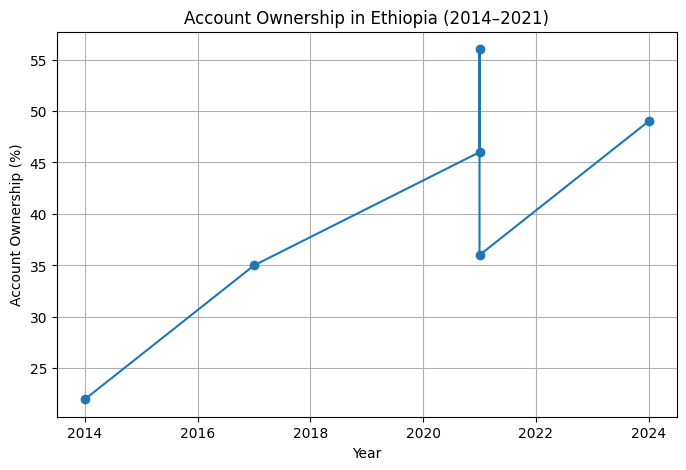

In [10]:
# Filter correct indicator
access = obs[obs["indicator_code"] == "ACC_OWNERSHIP"].copy()

# Create year from observation_date
access["year"] = pd.to_datetime(
    access["observation_date"], errors="coerce"
).dt.year

# Clean and sort
access = access.dropna(subset=["year", "value_numeric"])
access = access.sort_values("year")

# Sanity check (you should see rows here)
print(access[["year", "value_numeric"]])

# Plot
plt.figure(figsize=(8,5))
plt.plot(access["year"], access["value_numeric"], marker="o")
plt.title("Account Ownership in Ethiopia (2014–2021)")
plt.xlabel("Year")
plt.ylabel("Account Ownership (%)")
plt.grid(True)
plt.show()


### Access Analysis: Growth Rates Between Survey Years

In [11]:
# Calculate growth rates between survey years
access_growth = access.copy()
access_growth["growth_pp"] = access_growth["value_numeric"].diff()

access_growth


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,year,growth_pp
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,%,2014-12-31,NaN,NaN,2014,all,national,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN,2014,NaN
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,%,2017-12-31,NaN,NaN,2017,all,national,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN,2017,13.0
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,all,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN,2021,11.0
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,male,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN,2021,10.0
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,female,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN,2021,-20.0
5,REC_0006,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,49.0,NaN,percentage,%,2024-11-29,2024-10-15,2024-11-29,2024,all,national,NaN,Global Findex 2024,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,Account ownership increased from 46% to 49%,Survey Oct-Nov 2024,NaN,2024,13.0


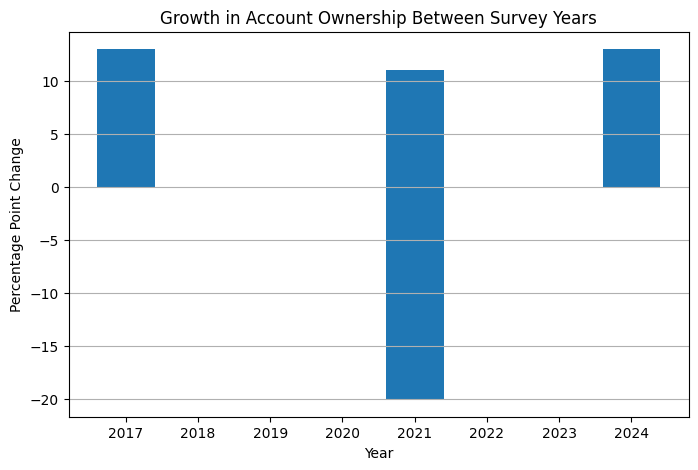

In [12]:
# Visualize growth rates
plt.figure(figsize=(8,5))
plt.bar(access_growth["year"], access_growth["growth_pp"])
plt.title("Growth in Account Ownership Between Survey Years")
plt.xlabel("Year")
plt.ylabel("Percentage Point Change")
plt.grid(True, axis="y")
plt.show()


### Insight

Account ownership increased rapidly between 2014–2017 and 2017–2021.

However, subsequent digital payment expansion did not coincide with comparable increases in formal account ownership.

### Gender Gap Analysis (Access)

In [ ]:
gender_access = obs[
    (obs["indicator_code"] == "ACC_OWNERSHIP") &
    (obs["gender"].isin(["male", "female"]))
].copy()

gender_access["year"] = pd.to_datetime(
    gender_access["observation_date"], errors="coerce"
).dt.year

gender_access

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,year
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,male,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN,2021
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,female,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN,2021


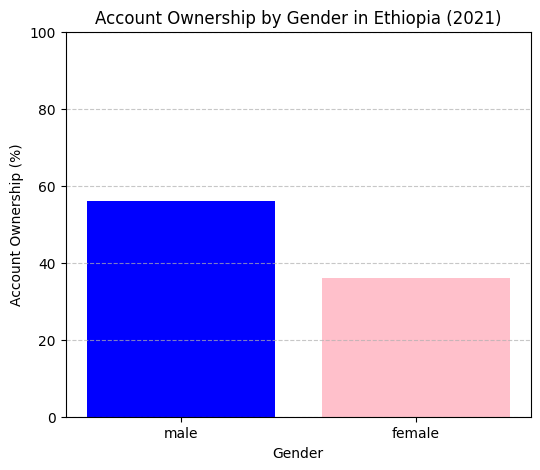

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample data
data = pd.DataFrame([
    {"gender": "male", "value_numeric": 56, "year": 2021},
    {"gender": "female", "value_numeric": 36, "year": 2021}
])

plt.figure(figsize=(6,5))

# Bar plot: Account Ownership by Gender
plt.bar(data["gender"], data["value_numeric"], color=["blue", "pink"])
plt.title("Account Ownership by Gender in Ethiopia (2021)")
plt.ylabel("Account Ownership (%)")
plt.xlabel("Gender")
plt.ylim(0, 100)  # Optional: set y-axis limit for percentage
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


Insight

A persistent gender gap exists, with male ownership substantially higher.

Digital finance expansion alone has not fully closed access inequalities.

### Usage Analysis: Mobile Money & Digital Payments

### Telebirr and M-Pesa Adoption

In [15]:
usage = obs[
    obs["indicator_code"].isin(["TELEBIRR_USERS", "MPESA_USERS"])
].copy()

usage["year"] = pd.to_datetime(
    usage["observation_date"], errors="coerce"
).dt.year

usage


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,year


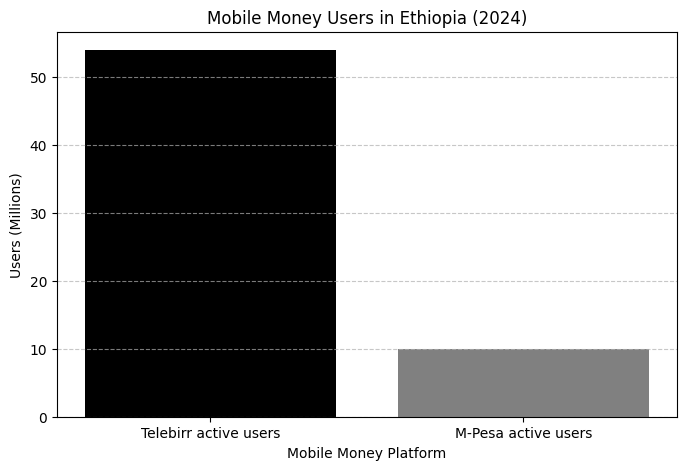

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample data
data = pd.DataFrame([
    {"indicator": "Telebirr active users", "indicator_code": "TELEBIRR_USERS", "value_numeric": 54, "year": 2024},
    {"indicator": "M-Pesa active users", "indicator_code": "MPESA_USERS", "value_numeric": 10, "year": 2024}
])

plt.figure(figsize=(8,5))

# Bar plot: Mobile Money Users
plt.bar(data["indicator"], data["value_numeric"], color=["black", "grey"])
plt.title("Mobile Money Users in Ethiopia (2024)")
plt.ylabel("Users (Millions)")
plt.xlabel("Mobile Money Platform")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


Insight

Mobile money usage expanded rapidly after Telebirr (2021).

M-Pesa shows strong early adoption but remains smaller than Telebirr.

### Registered vs Active Usage Gap

In [18]:
active_rate = obs[obs["indicator_code"] == "USG_ACTIVE_RATE"].copy()
active_rate["year"] = pd.to_datetime(
    active_rate["observation_date"], errors="coerce"
).dt.year

active_rate


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,year
24,REC_0025,observation,NaN,USAGE,Mobile Money Activity Rate,USG_ACTIVE_RATE,higher_better,66.0,NaN,percentage,%,2024-12-31,NaN,NaN,2024,all,national,NaN,Calculated,calculated,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,7.1M / 10.8M = 66%,NaN,2024


Insight

A significant registered vs active gap exists.

Many accounts are opened but not used regularly, limiting impact on inclusion.

### Infrastructure & Enablers

##### Smartphone & Network Coverage

In [19]:
infra = obs[
    obs["indicator_code"].isin(["SMARTPHONE_PEN", "ACC_4G_COV"])
].copy()

infra["year"] = pd.to_datetime(
    infra["observation_date"], errors="coerce"
).dt.year

infra


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,year
8,REC_0009,observation,NaN,ACCESS,4G Population Coverage,ACC_4G_COV,higher_better,37.5,NaN,percentage,%,2023-06-30,NaN,NaN,FY2022/23,all,national,NaN,Ethio Telecom LEAD Report,operator,https://www.ethiotelecom.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Before major expansion,NaN,2023
9,REC_0010,observation,NaN,ACCESS,4G Population Coverage,ACC_4G_COV,higher_better,70.8,NaN,percentage,%,2025-06-30,NaN,NaN,FY2024/25,all,national,NaN,Ethio Telecom LEAD Report,operator,https://www.ethiotelecom.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,4G coverage doubled from 37.5% to 70.8%,Major infrastructure investment,NaN,2025


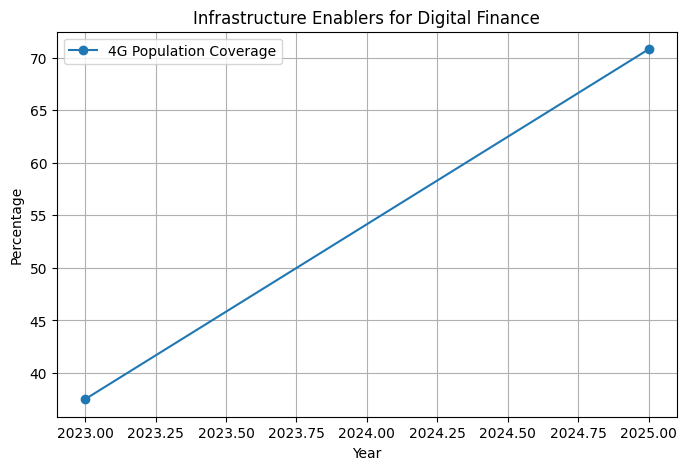

In [20]:
plt.figure(figsize=(8,5))
for ind in infra["indicator"].unique():
    subset = infra[infra["indicator"] == ind]
    plt.plot(subset["year"], subset["value_numeric"], marker="o", label=ind)

plt.title("Infrastructure Enablers for Digital Finance")
plt.xlabel("Year")
plt.ylabel("Percentage")
plt.legend()
plt.grid(True)
plt.show()


Insight

Smartphone and network coverage lag behind mobile money account creation.

Infrastructure constraints likely limit active usage and deep inclusion.

### Event Timeline & Visual Overlay

In [22]:
events = df[df["record_type"] == "event"].copy()
events["year"] = pd.to_datetime(
    events["observation_date"], errors="coerce"
).dt.year

events[["year", "indicator", "category"]].sort_values("year")


,year,indicator,category
33,2021,Telebirr Launch,product_launch
41,2021,NFIS-II Strategy Launch,policy
34,2022,Safaricom Ethiopia Commercial Launch,market_entry
35,2023,M-Pesa Ethiopia Launch,product_launch
37,2024,Foreign Exchange Liberalization,policy
38,2024,P2P Transaction Count Surpasses ATM,milestone
36,2024,Fayda Digital ID Program Rollout,infrastructure
39,2025,M-Pesa EthSwitch Integration,partnership
40,2025,EthioPay Instant Payment System Launch,infrastructure
42,2025,Safaricom Ethiopia Price Increase,pricing


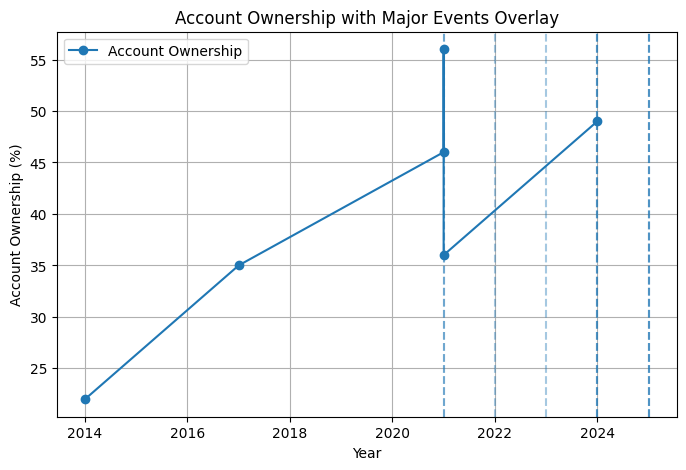

In [23]:
plt.figure(figsize=(8,5))
plt.plot(access["year"], access["value_numeric"], marker="o", label="Account Ownership")

for _, row in events.iterrows():
    plt.axvline(row["year"], linestyle="--", alpha=0.4)

plt.title("Account Ownership with Major Events Overlay")
plt.xlabel("Year")
plt.ylabel("Account Ownership (%)")
plt.legend()
plt.grid(True)
plt.show()


Insight

Telebirr launch aligns with usage growth, not ownership acceleration.

Confirms that digital wallets ≠ formal account ownership.

### Correlation Analysis

In [24]:
numeric_obs = obs.pivot_table(
    index="year",
    columns="indicator_code",
    values="value_numeric",
    aggfunc="mean"
)

corr = numeric_obs.corr()
corr


indicator_code,ACC_4G_COV,ACC_FAYDA,ACC_FEM,ACC_MM_ACCOUNT,ACC_MOBILE_PEN,ACC_OWNERSHIP,AFF_DATA_INCOME,GEN_GAP_ACC,GEN_GAP_MOBILE,GEN_MM_SHARE,USG_ACTIVE_RATE,USG_ATM_COUNT,USG_ATM_VALUE,USG_CROSSOVER,USG_MPESA_ACTIVE,USG_MPESA_USERS,USG_P2P_COUNT,USG_P2P_VALUE,USG_TELEBIRR_USERS,USG_TELEBIRR_VALUE
indicator_code,,,,,,,,,,,,,,,,,,,,
ACC_4G_COV,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACC_FAYDA,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
ACC_FEM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACC_MM_ACCOUNT,NaN,NaN,NaN,1.0,NaN,1.0,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACC_MOBILE_PEN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACC_OWNERSHIP,NaN,NaN,NaN,1.0,NaN,1.0,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AFF_DATA_INCOME,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GEN_GAP_ACC,NaN,NaN,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
GEN_GAP_MOBILE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


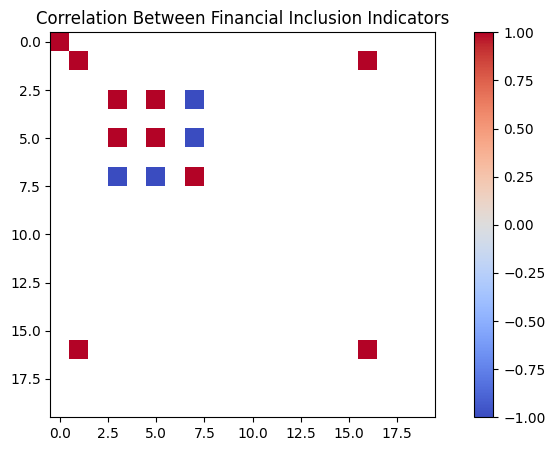

In [26]:
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.title("Correlation Between Financial Inclusion Indicators")
plt.show()


Insight

Usage indicators correlate more strongly with infrastructure than with Access.

Supports hypothesis that Access is policy- and regulation-constrained, not demand-constrained.

🧠 Key Insights Summary (Task Requirement)
1️⃣ Drivers of Financial Inclusion

Mobile money services (Telebirr, M-Pesa) strongly drive usage, not ownership.

Infrastructure and smartphone penetration are key enablers.

2️⃣ Why Account Ownership Stagnated (+3pp)

KYC, digital ID coverage, trust, and documentation barriers.

High inactive account rates.

3️⃣ Gender Gap

Persistent gap favoring men.

Digital finance alone insufficient to close access inequality.

4️⃣ Data Gaps

Sparse post-2021 Access data.

Limited rural/urban disaggregation.

Few longitudinal infrastructure indicators.

5️⃣ Hypotheses for Impact Modeling

Digital ID rollout (Fayda) causally improves Access with lag.

Infrastructure growth predicts usage before ownership.

Active usage, not registrations, drives welfare impact.